In [1]:
from readers import viirs_utils as v_utils
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import datetime
import matplotlib.colors as mcolors
import numpy as np

In [2]:
today_date_str = datetime.now().strftime("%Y_%m_%d")

## Plot Day/Night Band

In [3]:
dnb_dir = "data/dnb/" 
dnb_file = "GDNBO-SVDNB_j01_d20250312_t0639527_e0645327_b37894_c20250912025655090196_oebc_ops.h5"
file_path = os.path.join(dnb_dir, dnb_file)

In [4]:
v_utils.print_viirs_file_metadata(file_path)
v_utils.print_viirs_file_attrs(file_path, dataset="Data_Products/VIIRS-DNB-GEO/VIIRS-DNB-GEO_Gran_0")

Group: All_Data
Group: All_Data/VIIRS-DNB-GEO_All
Dataset: All_Data/VIIRS-DNB-GEO_All/Height | shape: (3072, 4064) | dtype: float32
Dataset: All_Data/VIIRS-DNB-GEO_All/Height_TC | shape: (3072, 4064) | dtype: float32
Dataset: All_Data/VIIRS-DNB-GEO_All/Latitude | shape: (3072, 4064) | dtype: float32
Dataset: All_Data/VIIRS-DNB-GEO_All/Latitude_TC | shape: (3072, 4064) | dtype: float32
Dataset: All_Data/VIIRS-DNB-GEO_All/Longitude | shape: (3072, 4064) | dtype: float32
Dataset: All_Data/VIIRS-DNB-GEO_All/Longitude_TC | shape: (3072, 4064) | dtype: float32
Dataset: All_Data/VIIRS-DNB-GEO_All/LunarAzimuthAngle | shape: (3072, 4064) | dtype: float32
Dataset: All_Data/VIIRS-DNB-GEO_All/LunarZenithAngle | shape: (3072, 4064) | dtype: float32
Dataset: All_Data/VIIRS-DNB-GEO_All/MidTime | shape: (192,) | dtype: int64
Dataset: All_Data/VIIRS-DNB-GEO_All/ModeGran | shape: (4,) | dtype: uint8
Dataset: All_Data/VIIRS-DNB-GEO_All/ModeScan | shape: (192,) | dtype: uint8
Dataset: All_Data/VIIRS-DNB-G

In [5]:
da = v_utils.open_dnb_radiance(file_path)
print(da)

--- Following error codes removed ---
VDNE (32-bit): 65024 occurrences
<xarray.DataArray 'Radiance' (y: 3056, x: 4064)> Size: 50MB
array([[-1.5000000e-09,  1.4021640e-08,  1.9812914e-08, ...,
         3.0349279e-09,  3.2330718e-09,  5.0676490e-09],
       [-1.5000000e-09,  9.4457064e-09,  1.1520949e-08, ...,
         2.5479159e-09,  3.6397751e-09,  5.8042100e-09],
       [-1.5000000e-09,  7.5233260e-09,  6.2221366e-09, ...,
         3.9099786e-09,  4.8137645e-09,  5.9191190e-09],
       ...,
       [-1.5000000e-09,  2.6718168e-09,  2.2437294e-09, ...,
         2.8543998e-09,  2.6460067e-09,  3.0599088e-09],
       [-1.5000000e-09,  5.1108819e-09,  3.4336356e-09, ...,
         2.8013429e-09,  3.0047713e-09,  3.0814828e-09],
       [-1.5000000e-09,  6.1209695e-09,  4.8136424e-09, ...,
         2.8722944e-09,  2.8737785e-09,  2.4620095e-09]],
      shape=(3056, 4064), dtype=float32)
Coordinates:
    Latitude   (y, x) float32 50MB 53.69 53.69 53.69 53.69 ... 27.39 27.38 27.36
    Longitude

In [6]:
description = f"{dnb_file.split("_")[1]} {dnb_file.split("_")[2]} {dnb_file.split("_")[3]}"
plot_title = f"VIIRS Day/Night Band \n {description}"
pin_coords = None
extent=[-73, -57, 33, 46] #[west, east, south, north]

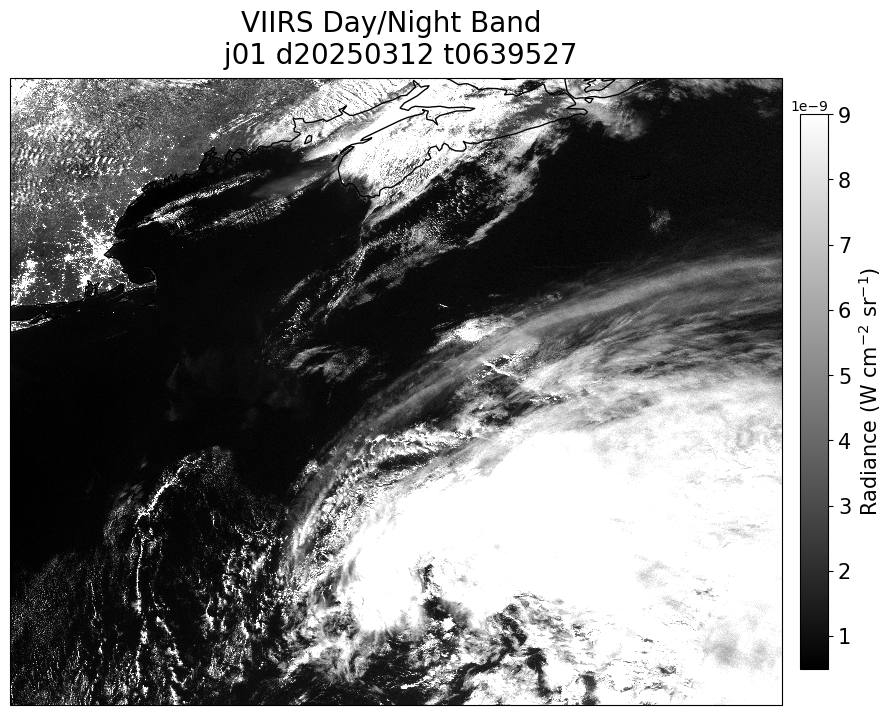

In [7]:
projection=ccrs.PlateCarree(central_longitude=0)
fig,ax=plt.subplots(1, figsize=(12,12), subplot_kw={'projection': projection})

cmap = "binary_r"
pcm = plt.pcolormesh(da["Longitude"], da["Latitude"], da, cmap=cmap, shading="nearest", vmin=0.5e-9, vmax=9e-9)

clb = plt.colorbar(pcm, shrink=0.6, pad=0.02, ax=ax)
clb.ax.tick_params(labelsize=15)
clb.set_label('Radiance (W cm$^{-2}$ sr$^{-1}$)', fontsize=15)

if pin_coords:
    ax.plot(pin_coords[1], pin_coords[0], 
        marker='o', 
        markersize=12,
        markerfacecolor='red',
        markeredgecolor='white',
        markeredgewidth=1.5, 
        transform=ccrs.PlateCarree())
if extent: ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.set_title(plot_title, fontsize=20, pad=10)
ax.coastlines(resolution='50m', color='black', linewidth=1)

plt.savefig(f"plots/{today_date_str}_viirs_dnb.png", dpi=200, bbox_inches='tight')
plt.show()

## Plot VIIRS brightness temperature

In [8]:
viirs_dir = "data/viirs/"
viirs_file = "GMTCO-SVM12-SVM13-SVM15_j01_d20250312_t0639527_e0645327_b37894_c20251017052332443046_oebc_ops.h5"
file_path = os.path.join(viirs_dir, viirs_file)

da_sw = v_utils.open_viirs_brightness_temp(file_path, "M12")
da_lw = v_utils.open_viirs_brightness_temp(file_path, "M15")
da_btd = da_lw - da_sw


--- Following error codes removed ---
VDNE (32-bit): 51200 occurrences
Identified scale and offset as 0.002518045948818326, 203.0
--- Following error codes removed ---
VDNE (32-bit): 51200 occurrences
Identified scale and offset as 0.004120438825339079, 111.0


In [9]:
def _print_value_at_point(da, pin_coords):
    dist = ((da['Latitude'] - pin_coords[0])**2 + (da['Longitude'] - pin_coords[1])**2)**0.5
    y_idx, x_idx = np.unravel_index(dist.argmin(), dist.shape)
    pin_value = da.isel(y=y_idx, x=x_idx).item()
    selected_lat = da['Latitude'].isel(y=y_idx, x=x_idx).item()
    selected_lon = da['Longitude'].isel(y=y_idx, x=x_idx).item()
    print(f"Value at ({selected_lat:.2f}, {selected_lon:.2f}): {pin_value:.2f} K")
    return

In [10]:
description = f"{viirs_file.split("_")[1]} {viirs_file.split("_")[2]} {viirs_file.split("_")[3]}"
plot_title = f"VIIRS M15 - M12 (10.76 μm - 3.7 μm) BTD \n {description}"
extent=[-73, -57, 33, 46]
pin_coords=(36, -72)

Value at (36.00, -72.00): 0.00 K


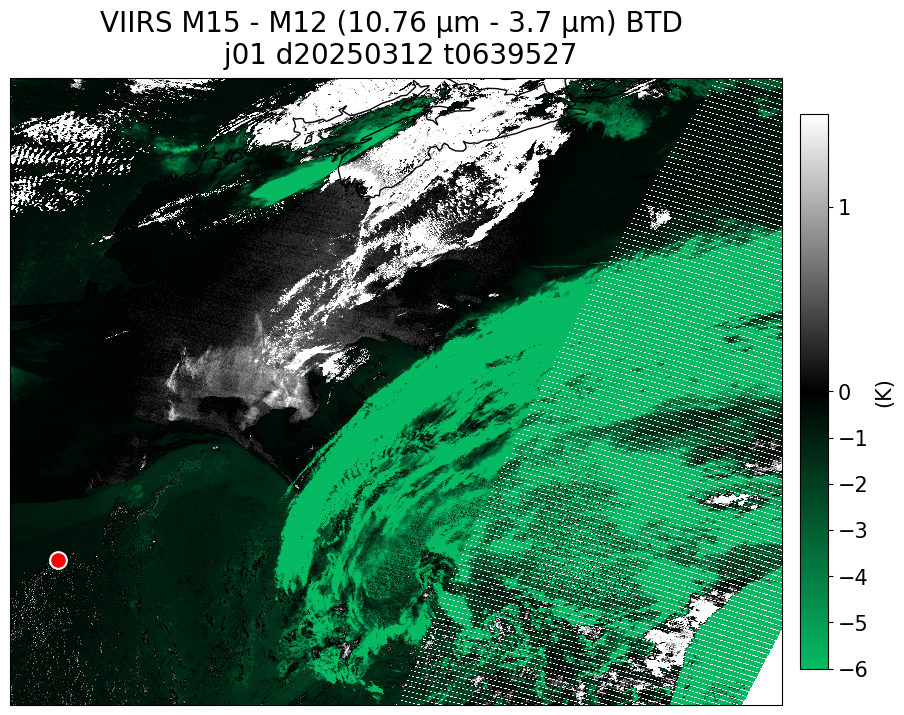

In [11]:
projection=ccrs.PlateCarree(central_longitude=0)
fig,ax=plt.subplots(1, figsize=(12,12), subplot_kw={'projection': projection})

cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0, "#06BA63"), (0.5, "black"), (1, "white")]
)
norm = mcolors.TwoSlopeNorm(vmin=-6, vcenter=0, vmax=1.5)

pcm = plt.pcolormesh(da_btd["Longitude"], da_btd["Latitude"], da_btd, cmap=cmap, norm=norm, shading="nearest")

clb = plt.colorbar(pcm, shrink=0.6, pad=0.02, ax=ax)
clb.ax.tick_params(labelsize=15)
clb.set_label('(K)', fontsize=15)

if pin_coords:
    ax.plot(pin_coords[1], pin_coords[0], 
        marker='o', 
        markersize=12,
        markerfacecolor='red',
        markeredgecolor='white',
        markeredgewidth=1.5, 
        transform=ccrs.PlateCarree())
    
    _print_value_at_point(da, pin_coords)

if extent: ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.set_title(plot_title, fontsize=20, pad=10)
ax.coastlines(resolution='50m', color='black', linewidth=1)

plt.savefig(f"plots/{today_date_str}_viirs_btd.png", dpi=200, bbox_inches='tight')
plt.show()

## Plot VIIRS spectral response function

* Using sensor response function file downloaded from https://ncc.nesdis.noaa.gov/VIIRS/VIIRSSpectralResponseFunctions.php


In [16]:
srf_file = "data/spectral_response_functions/NPP_VIIRS_NG_RSR_M12_filtered_Oct2011f_BA.dat"

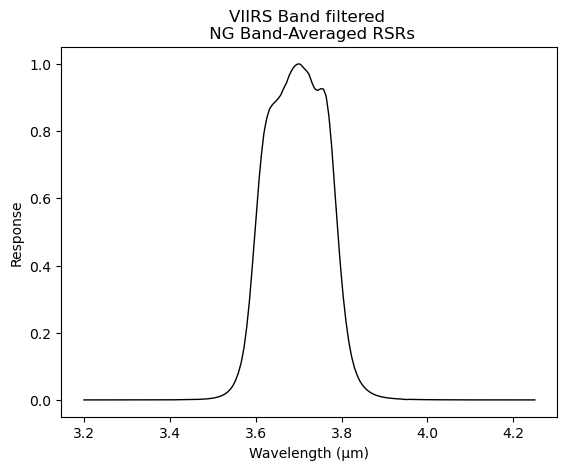

In [17]:
srf = np.loadtxt(srf_file)
x = srf[:, 0]/1000
y = srf[:, 1]
band_str = f'VIIRS Band {srf_file.split("_")[7]}'

plt.plot(x, y, color='black', linewidth=1)
plt.xlabel('Wavelength (µm)')
plt.ylabel('Response')
plt.title(f'{band_str} \n NG Band-Averaged RSRs')

plt.savefig(f"plots/{today_date_str}_viirs_srf.png", dpi=200, bbox_inches='tight')
plt.show()